# Phase 1: Supervised Learning

# Model 1: Random Forest

## 1️⃣ Model Selection Rationale
- **Why Random Forest**  
  - Handles nonlinear relationships in medical data  
  - Reduces overfitting compared to a single tree  
  - Works well with small tabular datasets (~583 rows)  
  - Provides feature importance for interpretability  

- **Strengths**
  - Robust to noise
  - Handles nonlinear patterns
  - Minimal scaling required
  - Feature importance visualization

- **Weaknesses**
  - Less interpretable than Logistic Regression
  - Higher computational cost
  - Can overfit if not tuned

---

## 2️⃣ Data Preparation
- Load the dataset (`Dataset/preprocessed_data.csv`)
- Encode categorical features (Gender → 0/1)
- Separate `X` (features) and `y` (target)
- Train/Test split (e.g., 80/20)
- Optional: check class balance

1️⃣ Model Selection Rationale

Why Random Forest?

Dataset: 583 samples, mostly numeric features.

Problem: Binary classification (Dataset column: liver disease yes/no).

Relationships between medical variables may be nonlinear.

Random Forest handles nonlinear patterns and reduces overfitting compared to a single decision tree.

Provides feature importance, which is great for interpretability in medical data.

Strengths:

Robust to noise

Handles nonlinear relationships

Works well without scaling

Can generate feature importance plots

Weaknesses:

Less interpretable than Logistic Regression

Higher computational cost than a single tree

Can still overfit if not tuned

Use in Project:
We are training the model to predict liver disease based on patient features. Later, this prediction will inform the advice system (“Consult a hepatologist” or “Routine check-up”).

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("Dataset/preprocessed_data.csv")

# Check first rows
df.head()

# Features and target
X = df.drop("Dataset", axis=1)
y = df["Dataset"]

# Encode Gender if not already numeric (0=Female, 1=Male)
# (Looks like your CSV already has 0/1, so skip encoding)

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Optional: scale features (Random Forest doesn't strictly need it)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Baseline model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

# Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# GridSearchCV with 5-fold cross-validation
grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',  # Emphasize recall/precision for medical data
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:", grid_rf.best_params_)
print("Best CV F1 Score:", grid_rf.best_score_)

In [ ]:
# Best model
best_rf = grid_rf.best_estimator_

# Feature importance
importances = best_rf.feature_importances_
features = X.columns
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

# Plot
sns.barplot(x=feat_imp, y=feat_imp.index)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Random Forest")
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_rf, X, y, cv=5, scoring='f1')
print(f"5-Fold CV F1 Score: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# Model 2 : Logistic Regression

## 1️⃣ Model Selection Rationale

### Why Logistic Regression?
* **Suitable for binary classification:** Specifically for predicting liver disease vs. no disease.
* **Handles small-to-medium datasets:** Works effectively with tabular data like the Indian Liver Patient Records (~583 rows).
* **Interpretable coefficients:** Provides clear insights into how each medical feature impacts the diagnosis.
* **Strong baseline model:** Serves as a perfect point of comparison for more complex models like Random Forest.
* **Efficiency:** Extremely fast to train and deploy.

### ✅ Strengths
* **High Interpretability:** The model's coefficients directly show the impact of each feature.
* **Low Computational Cost:** Requires very little memory and processing power.
* **Linear Relationships:** Performs exceptionally well when the relationship between features is approximately linear.
* **Probability Outputs:** It doesn't just classify; it gives a probability score which is vital for medical risk prediction.
* **Robustness:** Less prone to overfitting on smaller datasets compared to deep trees.

### ❌ Weaknesses
* **Linear Assumption:** It assumes a linear relationship between the features and the log-odds of the outcome.
* **Complexity Issues:** Might struggle with highly complex, non-linear patterns in medical data.
* **Multicollinearity:** It is sensitive to features that are highly correlated with each other.
* **Requirement for Scaling:** Needs proper feature scaling (like StandardScaler) to achieve optimal performance.
  

# Logistic Regression Data Preparation
This section prepares the dataset for training a Logistic Regression model. 
It includes loading data, splitting into features and target, train-test split, and feature scaling.

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve
from sklearn.preprocessing import StandardScaler
import joblib

# ---------------------------------------------
# 1️⃣ Load the dataset
# ---------------------------------------------
df = pd.read_csv("preprocessed_data.csv")

# ---------------------------------------------
# 2️⃣ Separate features (X) from the target variable (y)
# "Dataset" column is assumed to be the target.
# ---------------------------------------------
X = df.drop("Dataset", axis=1)
y = df["Dataset"]

# ---------------------------------------------
# 3️⃣ Split the data into training and testing sets
# 80% training, 20% testing, with stratification to maintain class distribution
# ---------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------------------------------------
# 4️⃣ Feature Scaling
# Logistic Regression is sensitive to feature scales.
# StandardScaler standardizes features by removing the mean and scaling to unit variance.
# ---------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Data is ready and scaled!")

✅ Data is ready and scaled!


# Logistic Regression Model Building
This section demonstrates building, training, and predicting with a Logistic Regression model for binary classification.

In [5]:
# Importing the necessary library
from sklearn.linear_model import LogisticRegression

# ------------------------------
# Step 1: Initialize the model
# ------------------------------
# Setting random_state for reproducibility and max_iter to ensure convergence
log_reg = LogisticRegression(random_state=42, max_iter=1000)

# ------------------------------
# Step 2: Train the model
# ------------------------------
# Fitting the model on scaled training features and corresponding labels
log_reg.fit(X_train_scaled, y_train)

# ------------------------------
# Step 3: Make predictions
# ------------------------------
# Predict class labels for test set
y_pred = log_reg.predict(X_test_scaled)

# Predict probabilities for the positive class
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

# ------------------------------
# Step 4: Confirmation message
# ------------------------------
print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


#  Logistic Regression Evaluation
This section evaluates the trained Logistic Regression model using key metrics, plots, cross-validation, and saves the model for future use.

Logistic Regression Classification Report:

              precision    recall  f1-score   support

           1       0.76      0.95      0.85        81
           2       0.69      0.27      0.39        33

    accuracy                           0.75       114
   macro avg       0.73      0.61      0.62       114
weighted avg       0.74      0.75      0.71       114



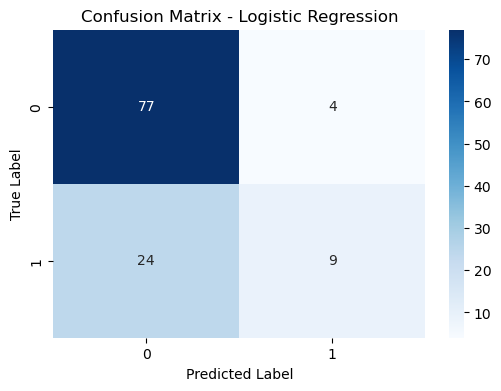

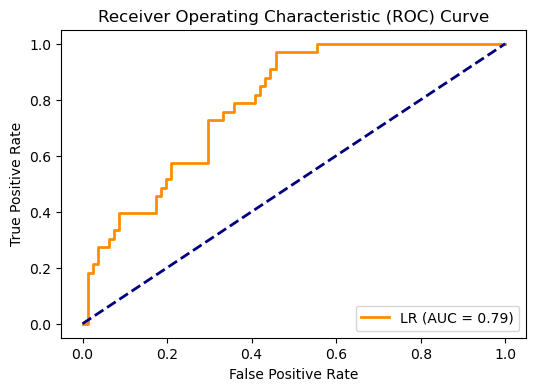

5-Fold Cross-Validation F1 Score: 0.814 ± 0.019

 All evaluation metrics generated, visualizations saved, and model exported successfully!


In [10]:
from sklearn.model_selection import cross_val_score
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import pandas as pd

# ==========================================
# 1. COMPREHENSIVE EVALUATION
# ==========================================
# Evaluate the Logistic Regression model using classification metrics, confusion matrix, and ROC curve

# Generate and print classification report
print("Logistic Regression Classification Report:\n")
lr_report = classification_report(y_test, y_pred)  
print(lr_report)

# Plot and save Confusion Matrix as heatmap
plt.figure(figsize=(6,4))
cm_lr = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig('Supervised_Learning/evaluation_results/lr_confusion_matrix.png')
plt.show()

# Plot and save ROC-AUC curve
# Specify pos_label=2 because y_test contains {1,2} 
lr_roc_auc = roc_auc_score(y_test, y_prob)
fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label=2)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'LR (AUC = {lr_roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.savefig('Supervised_Learning/plots/lr_roc_curve.png')
plt.show()

# ==========================================
# 2. K-FOLD CROSS-VALIDATION (k=5)
# ==========================================
# Assess model generalization using 5-fold cross-validation on training data
cv_f1_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=5, scoring='f1')
print(f"5-Fold Cross-Validation F1 Score: {cv_f1_scores.mean():.3f} ± {cv_f1_scores.std():.3f}")

# ==========================================
# 3. MODEL PERSISTENCE & DELIVERABLES
# ==========================================
# Save trained model and scaler for future predictions or deployment
joblib.dump(log_reg, 'Supervised_Learning/models/logistic_regression_model.pkl')
joblib.dump(scaler, 'Supervised_Learning/models/lr_scaler.pkl')

# Export classification metrics to CSV for documentation and reporting
report_dict = classification_report(y_test, y_pred, output_dict=True)
pd.DataFrame(report_dict).transpose().to_csv('Supervised_Learning/evaluation_results/lr_metrics_report.csv')

print("\n All evaluation metrics generated, visualizations saved, and model exported successfully!")